In [1]:
!pip install --q imbalanced-learn
!pip install fosforml 
!pip install fosforio
!pip install seaborn

You should consider upgrading via the 'pip install --upgrade pip' command.
     |████████████████████████████████| 51kB 5.0MB/s eta 0:00:011
     |████████████████████████████████| 1.9MB 26.0MB/s eta 0:00:01
     |████████████████████████████████| 10.9MB 83.5MB/s eta 0:00:01
     |████████████████████████████████| 1.5MB 101.6MB/s eta 0:00:01
     |████████████████████████████████| 98.7MB 278kB/s  eta 0:00:01
     |████████████████████████████████| 61kB 10.6MB/s eta 0:00:01
     |████████████████████████████████| 51kB 13.3MB/s  eta 0:00:01
     |████████████████████████████████| 133kB 106.1MB/s eta 0:00:01
     |████████████████████████████████| 40.1MB 96.0MB/s eta 0:00:01
     |████████████████████████████████| 174kB 83.3MB/s eta 0:00:01
     |████████████████████████████████| 2.5MB 118.2MB/s eta 0:00:01
     |████████████████████████████████| 200.3MB 111kB/s s eta 0:00:01B/s eta 0:00:01
     |████████████████████████████████| 81kB 27.4MB/s  eta 0:00:01
     |██████████████████████████

In [2]:
# Statitics and Basic data support
from scipy.stats.mstats import winsorize
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling Training and Tunning
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, recall_score, f1_score,log_loss, roc_auc_score,roc_curve, precision_recall_curve
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Imbalance Handling
from imblearn.over_sampling import SMOTE

# Addititional
from collections import Counter
import joblib

# Fosforml
from fosforml import register_model
from fosforml.constants import MLModelFlavours
from fosforml.model_manager.snowflakesession import get_session

# Warnings
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
warnings.filterwarnings("ignore", message="numpy.ufunc size changed")

In [3]:
from fosforml.model_manager.snowflakesession import get_session
my_session = get_session()

In [6]:
df = 'EMPLOYEE_ATTRITION_MASTERTABLE'

In [7]:
sf_df = my_session.sql("select * from {}".format(df))
df = sf_df.to_pandas()

In [8]:
Original_df = df

In [9]:
Original_df

,ROLE,LINE_OF_BUSINESS,DELIVERY_UNIT,PRACTICE_UNIT,EMPLOYMENT_TYPE,OVERTIME_HOURS,AVERAGE_PERCENTAGE_SALARY_HIKE,AVERAGE_PERFORMANCE_RATING,JOB_STARTDATE,JOB_ENDDATE,...,QUALIFICATION,ETHNICITY,MARITAL_STATUS,GENDER,CONTINENT,COUNTRY,STATE,CITY,LATITUDE,LONGITUDE
0,Associate Director,Energy,Consulting,Technology Consulting,Full-time,0,6,1,2018-10-19,2022-08-31,...,Masters Degree,Asian,Single,Female,Asia-Pacific,Australia,Victoria,Melbourne,37.8136,144.9631
1,Senior Principal,Media and Entertainment,Digital and Analytics,Artificial Intelligence,Full-time,24,2,1,2016-12-19,2021-06-29,...,Associates Degree,Caucasian,Single,Male,North America,Canada,Ontario,Mississauga,43.5890,79.6441
2,Specialist,Manufacturing,Enterprise IT Transformation,Application Development,Full-time,24,2,3,2022-04-21,None,...,Professional Degree,African American,Single,Male,North America,United States,Georgia,Alpharetta,34.0754,84.2941
3,Senior Software Engineer,Healthcare and Life Sciences,Assurance Services,Reliability Engineering,Full-time,18,8,4,2007-09-18,2012-07-14,...,Associates Degree,Caucasian,Married,Female,Asia-Pacific,Singapore,Singapore,Singapore City,1.3521,103.8198
4,Product Engineer,Travel Transportation and Hospitality (TTH),Digital and Analytics,Artificial Intelligence,Internship,12,4,3,2012-10-19,2017-01-01,...,Associates Degree,African,Married,Female,Middle East and Africa,South Africa,Johannesburg,Johannesburg City,26.2041,28.0473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,Principal,Retail and Consumer Goods,Consulting,Technology Consulting,Full-time,18,4,3,2024-04-20,2024-12-19,...,Associates Degree,Asian,Married,Male,Europe,Europe,France,Puteaux,48.8848,2.2399
299996,Associate Director,Manufacturing,Cloud and Infrastructure Services,Infrastructure Services,Full-time,24,4,2,2007-03-21,2007-06-15,...,Bachelors Degree,Asian,Married,Female,Asia-Pacific,India,Karnataka,Bangalore,12.9716,77.5946
299997,Senior Specialist,Energy,Consulting,Business Process Consulting,Full-time,8,4,1,2007-11-19,2010-09-21,...,Doctoral Degree,African American,Married,Female,North America,Mexico,Jalisco,Guadalajara,20.6597,103.3496
299998,Senior Vice President,Insurance,Assurance Services,Testing Services,Full-time,18,4,1,2019-12-19,2020-11-24,...,Professional Degree,African,Married,Female,Middle East and Africa,South Africa,Johannesburg,Johannesburg City,26.2041,28.0473


In [10]:
Employee_df = Original_df.drop(["EMPLOYEE_ID", "JOB_STARTDATE", "JOB_ENDDATE","AVERAGE_PERCENTAGE_SALARY_HIKE","AVERAGE_PERFORMANCE_RATING","SALARY_RANGE","LATITUDE","LONGITUDE"], axis = 1)

In [13]:
CATEGORICAL_COLUMNS = ["QUALIFICATION","ETHNICITY","MARITAL_STATUS","GENDER","CONTINENT","COUNTRY","STATE","CITY","ROLE","LINE_OF_BUSINESS","DELIVERY_UNIT",
                      "PRACTICE_UNIT","EMPLOYMENT_TYPE","TURNOVER_REASONS","SHIFT","SALARY_LEVEL","JOB_SATISFACTION","OVER_TIME","DISTANCE"]
NUMERICAL_COLUMNS = ["BIRTH_YEAR","AGE","SALARY_INR","OVERTIME_HOURS","TENURE_MONTHS"]
LABEL_COLUMNS = ["CHURN"]
DROPPED_COLUMNS = ["EMPLOYEE_ID", "JOB_STARTDATE", "JOB_ENDDATE","AVERAGE_PERCENTAGE_SALARY_HIKE","AVERAGE_PERFORMANCE_RATING","SALARY_RANGE","LATITUDE","LONGITUDE"]
OUTPUT_COLUMNS = ["PREDICTION"]

In [14]:
# Step 4: Train-Test Split
X = Employee_df[CATEGORICAL_COLUMNS + NUMERICAL_COLUMNS]
y = Employee_df[LABEL_COLUMNS].values.ravel()  # Ensure y is a 1D array

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
 
# Define transformers
categorical_transformer = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='missing'),
    OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
)
 
numerical_transformer = make_pipeline(
    SimpleImputer(strategy='mean'),
    MinMaxScaler(clip=True)
)
 
# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, CATEGORICAL_COLUMNS),
        ('num', numerical_transformer, NUMERICAL_COLUMNS)
    ]
)
 
# Create pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier())
])

pipeline.fit(X_train, y_train)
result = pipeline.predict(X_test)

In [16]:
from joblib import dump, load
filename = "HR_Attrition.joblib"
dump(pipeline, filename)

['HR_Attrition.joblib']

In [17]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)

In [18]:
result = pipeline.predict(X_test)
result_prob = pipeline.predict_proba(X_test)
pred_df = X_test.copy()
result = result
result_prob = result_prob
pred_df["PREDICTION"] = result
pred_df["PROB"] = result_prob[:, 1]

In [19]:
from sklearn.metrics import classification_report, log_loss, roc_auc_score
 
# Check lengths
print("Length of y_test:", len(y_test))
print("Length of y_pred:", len(y_pred))
 
# Print classification report
print(classification_report(y_test, y_pred))
 
# Calculate accuracy
accuracy = sum(y_test == y_pred) / len(y_test)
print("Accuracy:", accuracy)
 
# Calculate additional metrics
log_loss_value = log_loss(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob[:, 1])  # Assuming class 1 is the positive class
 
print("Log Loss:", log_loss_value)
print("ROC AUC Score:", roc_auc)

Length of y_test: 75000
Length of y_pred: 75000
              precision    recall  f1-score   support

           0       1.00      0.79      0.88     18622
           1       0.94      1.00      0.97     56378

    accuracy                           0.95     75000
   macro avg       0.97      0.90      0.93     75000
weighted avg       0.95      0.95      0.95     75000

Accuracy: 0.94816
Log Loss: 0.19390710550984117
ROC AUC Score: 0.9008921081699708


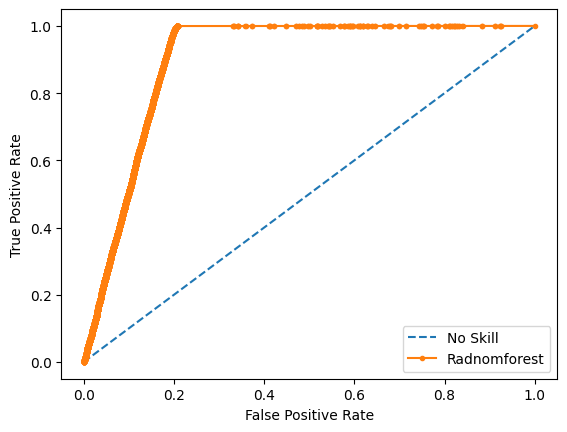

In [20]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot as plt
import seaborn as sns
ns_probs = [0 for _ in range(len(y_test))]
ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, pred_df["PROB"])
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, pred_df["PROB"])
# plot the roc curve for the model
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
plt.plot(lr_fpr, lr_tpr, marker='.', label='Radnomforest')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

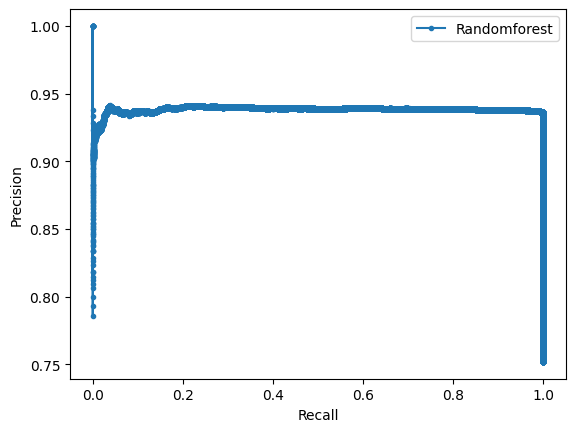

In [21]:
lr_precision, lr_recall, _ = precision_recall_curve(y_test, pred_df["PROB"])
plt.plot(lr_recall, lr_precision, marker='.', label='Randomforest')
# axis labels
plt.xlabel('Recall')
plt.ylabel('Precision')
# show the legend
plt.legend()
# show the plot
plt.show()

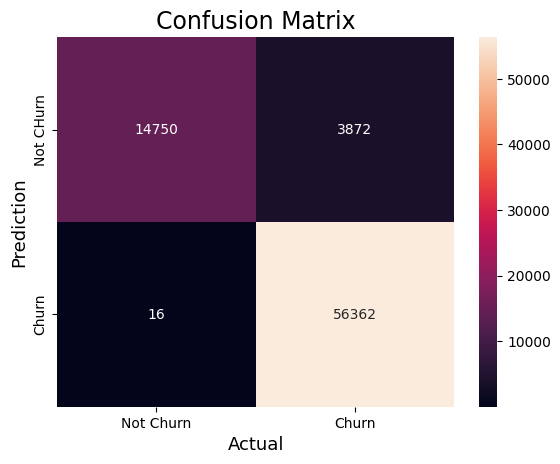

In [22]:
cm = confusion_matrix(y_test,y_pred)
 
#Plot the confusion matrix.
sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=['Not Churn','Churn'],
            yticklabels=['Not CHurn','Churn'])
plt.ylabel('Prediction',fontsize=13)
plt.xlabel('Actual',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()

In [23]:
# Define or use the prediction function
def model_prediction_score_func(dataframe):
    # Ensure 'dataframe' has the correct features required by the model
    return pipeline.predict(dataframe)  # Use your trained pipeline/model here
 
# Assuming df is your input DataFrame with the necessary features
Original_df['Model_Output'] = model_prediction_score_func(Original_df)

In [24]:
Original_df

,ROLE,LINE_OF_BUSINESS,DELIVERY_UNIT,PRACTICE_UNIT,EMPLOYMENT_TYPE,OVERTIME_HOURS,AVERAGE_PERCENTAGE_SALARY_HIKE,AVERAGE_PERFORMANCE_RATING,JOB_STARTDATE,JOB_ENDDATE,...,ETHNICITY,MARITAL_STATUS,GENDER,CONTINENT,COUNTRY,STATE,CITY,LATITUDE,LONGITUDE,Model_Output
0,Associate Director,Energy,Consulting,Technology Consulting,Full-time,0,6,1,2018-10-19,2022-08-31,...,Asian,Single,Female,Asia-Pacific,Australia,Victoria,Melbourne,37.8136,144.9631,1
1,Senior Principal,Media and Entertainment,Digital and Analytics,Artificial Intelligence,Full-time,24,2,1,2016-12-19,2021-06-29,...,Caucasian,Single,Male,North America,Canada,Ontario,Mississauga,43.5890,79.6441,1
2,Specialist,Manufacturing,Enterprise IT Transformation,Application Development,Full-time,24,2,3,2022-04-21,None,...,African American,Single,Male,North America,United States,Georgia,Alpharetta,34.0754,84.2941,1
3,Senior Software Engineer,Healthcare and Life Sciences,Assurance Services,Reliability Engineering,Full-time,18,8,4,2007-09-18,2012-07-14,...,Caucasian,Married,Female,Asia-Pacific,Singapore,Singapore,Singapore City,1.3521,103.8198,1
4,Product Engineer,Travel Transportation and Hospitality (TTH),Digital and Analytics,Artificial Intelligence,Internship,12,4,3,2012-10-19,2017-01-01,...,African,Married,Female,Middle East and Africa,South Africa,Johannesburg,Johannesburg City,26.2041,28.0473,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,Principal,Retail and Consumer Goods,Consulting,Technology Consulting,Full-time,18,4,3,2024-04-20,2024-12-19,...,Asian,Married,Male,Europe,Europe,France,Puteaux,48.8848,2.2399,1
299996,Associate Director,Manufacturing,Cloud and Infrastructure Services,Infrastructure Services,Full-time,24,4,2,2007-03-21,2007-06-15,...,Asian,Married,Female,Asia-Pacific,India,Karnataka,Bangalore,12.9716,77.5946,1
299997,Senior Specialist,Energy,Consulting,Business Process Consulting,Full-time,8,4,1,2007-11-19,2010-09-21,...,African American,Married,Female,North America,Mexico,Jalisco,Guadalajara,20.6597,103.3496,1
299998,Senior Vice President,Insurance,Assurance Services,Testing Services,Full-time,18,4,1,2019-12-19,2020-11-24,...,African,Married,Female,Middle East and Africa,South Africa,Johannesburg,Johannesburg City,26.2041,28.0473,1


In [25]:
Original_df.to_csv("EMPLOYEE_ATTRITION_DATA_PREDICTIVE.csv", index=False)
import pandas as pd
if 'Model_Output' in Original_df:
    Original_df['Model_Output_Values'] = Original_df['Model_Output'].astype(bool)
print(Original_df.head())

                       ROLE                             LINE_OF_BUSINESS   
0        Associate Director                                       Energy  \
1          Senior Principal                      Media and Entertainment   
2                Specialist                                Manufacturing   
3  Senior Software Engineer                 Healthcare and Life Sciences   
4          Product Engineer  Travel Transportation and Hospitality (TTH)   

                  DELIVERY_UNIT            PRACTICE_UNIT EMPLOYMENT_TYPE   
0                    Consulting    Technology Consulting       Full-time  \
1         Digital and Analytics  Artificial Intelligence       Full-time   
2  Enterprise IT Transformation  Application Development       Full-time   
3            Assurance Services  Reliability Engineering       Full-time   
4         Digital and Analytics  Artificial Intelligence      Internship   

   OVERTIME_HOURS  AVERAGE_PERCENTAGE_SALARY_HIKE  AVERAGE_PERFORMANCE_RATING   
0    

In [26]:
sf_df = my_session.createDataFrame(Original_df)
sf_df.write.mode("overwrite").save_as_table("EMPLOYEE_ATTRITION_DATA_PREDICTIVE")
my_session.table("EMPLOYEE_ATTRITION_DATA_PREDICTIVE").show()

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"ROLE"                    |"LINE_OF_BUSINESS"                           |"DELIVERY_UNIT"                    |"PRACTICE_UNIT"              |"EMPLOYMENT_TYPE"  |"OVERTIME_HOURS"  |"AVERAGE_PERCENTAGE_SALARY_HIKE"  |"AVERAGE_PERFORMANCE_RATING"  |"JOB_STARTDATE"  |"JOB_END